In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Параметры задачи и известные функции
a = -1
b = 1
N = 400
k = 10



x = np.linspace(a, b, N + 1)

grid_x = (x[1:] + x[:-1]) / 2
h = x[1] - x[0]

def eta1(x):
    return (1.42 - 0.05j) * (x < 0.6) * (x > -0.6)

def u0(x, k):
    return np.exp(1j * k * x)

def G(x, y, k):
    return 1j / (2 * k) * np.exp(1j * k * np.abs(x - y))

$$
(I + k^2 \cdot \eta_{j} \cdot G_{i, j} \cdot h) \cdot U_j = U0_i
$$

In [ ]:
# Сборка матрицы оператора
K = (
    h * k**2 *
    G(grid_x[None, :], grid_x[:, None], k) *
    eta1(grid_x[None, :])
    +
    np.eye(N)
    )

Text(0, 0.5, 'Строки')

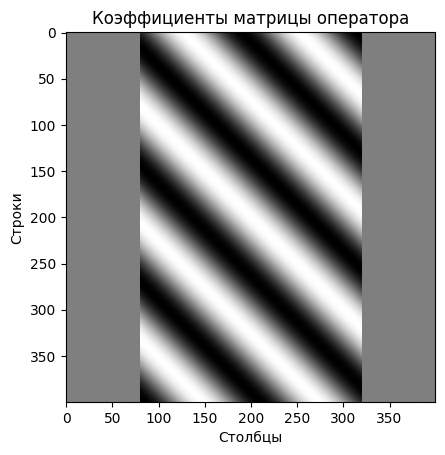

In [ ]:
plt.imshow(K.imag, cmap = 'gray')
plt.title("Коэффициенты матрицы оператора")
plt.xlabel("Столбцы")
plt.ylabel("Строки")

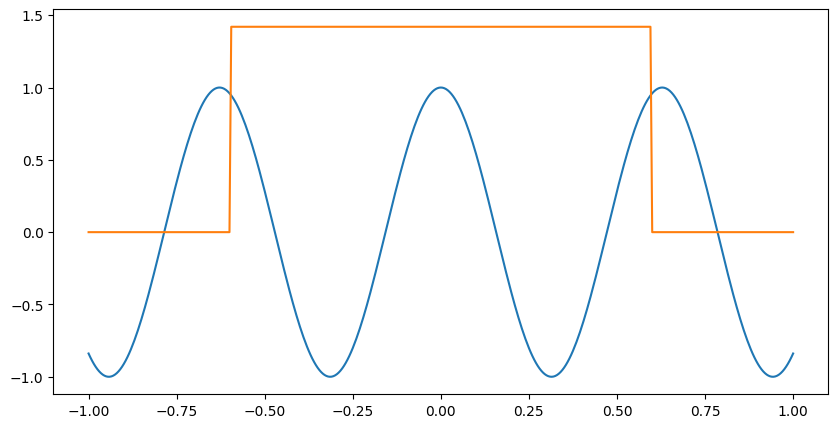

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x, u0(x, k).real)
plt.plot(x, eta1(x))

In [ ]:
# Решение СЛАУ
u = np.linalg.solve(K, u0(grid_x, k))

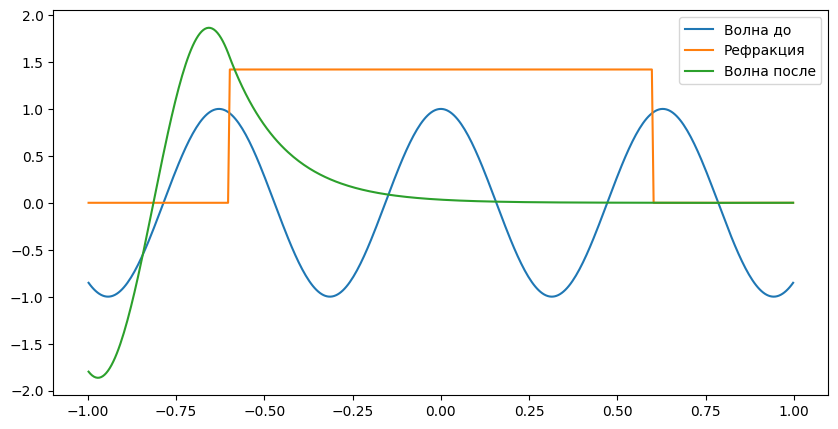

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(grid_x, u0(grid_x, k).real, label = "Волна до")
plt.plot(grid_x, eta1(grid_x).real, label = "Рефракция")
plt.plot(grid_x, u.real, label = "Волна после")
plt.legend()
plt.show()

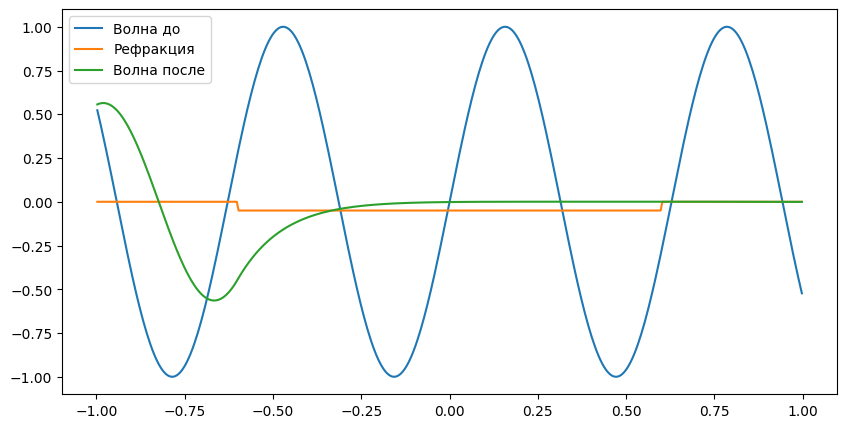

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(grid_x, u0(grid_x, k).imag, label = "Волна до")
plt.plot(grid_x, eta1(grid_x).imag, label = "Рефракция")
plt.plot(grid_x, u.imag, label = "Волна после")
plt.legend()
plt.show()